In [1]:
from game_theory_experiments import (
    BasicGamesExperimentResult,
    BattleOfSexesActionsType,
    CheapTalkResponse,
    DictatorshipGameResult,
    PrisonersDilemmaActionsType,
    UltimatumGameResult,
)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import pandas as pd

In [2]:
with open("../results/prisoners_dilemma_basic.json") as f:
    prisoners_dilemma_basic = BasicGamesExperimentResult[
        PrisonersDilemmaActionsType
    ].model_validate_json(f.read())
with open("../results/prisoners_dilemma_cheap_talk.json") as f:
    prisoners_dilemma_cheap_talk = BasicGamesExperimentResult[
        CheapTalkResponse[PrisonersDilemmaActionsType]
    ].model_validate_json(f.read())
with open("../results/battle_of_sexes_basic.json") as f:
    battle_of_sexes_basic = BasicGamesExperimentResult[
        BattleOfSexesActionsType
    ].model_validate_json(f.read())
with open("../results/battle_of_sexes_cheap_talk.json") as f:
    battle_of_sexes_cheap_talk = BasicGamesExperimentResult[
        CheapTalkResponse[BattleOfSexesActionsType]
    ].model_validate_json(f.read())
with open("../results/dictatorship_game.json") as f:
    dictatorship_game = DictatorshipGameResult.model_validate_json(f.read())
with open("../results/ultimatum_game.json") as f:
    ultimatum_game = UltimatumGameResult.model_validate_json(f.read())

In [3]:
def aggregate_results_basic[TAction: str](results: BasicGamesExperimentResult[TAction]):
    rows = [
        {"action_1": resp1.answer, "action_2": resp2.answer}
        if resp1.answer <= resp2.answer
        else {"action_1": resp2.answer, "action_2": resp1.answer}
        for result in results.results
        for resp1, resp2 in [result.responses]
    ]
    display(pd.DataFrame(rows).groupby(["action_1", "action_2"]).size().reset_index(name="count"))


print("Prisoner's Dilemma - Basic")
aggregate_results_basic(prisoners_dilemma_basic)
print()
print("Battle of the Sexes - Basic")
aggregate_results_basic(battle_of_sexes_basic)

Prisoner's Dilemma - Basic


,action_1,action_2,count
0,betray,betray,50



Battle of the Sexes - Basic


,action_1,action_2,count
0,Football,Football,3
1,Football,Opera,37
2,Opera,Opera,9


In [4]:
def aggregate_results_cheap_talk[TAction: str](
    results: BasicGamesExperimentResult[CheapTalkResponse[TAction]],
):
    rows = [
        {
            "coordinated_1": resp1.answer.coordinated_on_strategy,
            "coordinated_2": resp2.answer.coordinated_on_strategy,
            "final_1": resp1.answer.final_answer,
            "final_2": resp2.answer.final_answer,
        }
        for result in results.results
        for resp1, resp2 in [result.responses]
    ]
    display(pd.DataFrame(rows).groupby(["coordinated_1", "coordinated_2", "final_1", "final_2"]).size().reset_index(name="count"))

print("Prisoner's Dilemma - Cheap Talk")
aggregate_results_cheap_talk(prisoners_dilemma_cheap_talk)
print()
print("Battle of the Sexes - Cheap Talk")
aggregate_results_cheap_talk(battle_of_sexes_cheap_talk)   

Prisoner's Dilemma - Cheap Talk


,coordinated_1,coordinated_2,final_1,final_2,count
0,betray,betray,betray,betray,1
1,betray,stay silent,betray,betray,6
2,betray,stay silent,betray,stay silent,1
3,stay silent,betray,betray,betray,6
4,stay silent,betray,stay silent,betray,3
5,stay silent,stay silent,betray,betray,13
6,stay silent,stay silent,betray,stay silent,6
7,stay silent,stay silent,stay silent,betray,7
8,stay silent,stay silent,stay silent,stay silent,7



Battle of the Sexes - Cheap Talk


,coordinated_1,coordinated_2,final_1,final_2,count
0,Football,Football,Football,Football,10
1,Football,Opera,Football,Opera,19
2,Opera,Football,Opera,Football,1
3,Opera,Opera,Opera,Opera,19


### Results

As we can see, in the Prisoners dilemma without the cheap talk, all of the agents betray, which is their Nash equilibrium.
The situation is more diverse when we allow cheap talk for possible coordination.
In the 7 cases the agents agree to `stay silent` strategy and follow it.
In 13 cases the agents coordinated on staying silent, however one of them betrayed and in 13 more cases both of the agents betrayed.
In 12 cases one of the agent unilateraly think they agreed on staying silent, but they betrayed anyway.
In 4 cases one of the agent chose to stay silent and the other to betray and their followed their cheap talk strategy.
In single case they choose to betray even in the cheap talk and they followed their strategy.

As a result of Prisoners dilemma, the agents are keen on discussing their strategy, but they still betray and play their Nash equilibria.

The situation is however different for battle of sexes.
In the original version, they miscoordinated in 37 timesand they have a coordinated optimal action in 12 cases.

In the cheap talk version, they miscoordinated only 20 times, while having 29 times a common action.
The agents have a different opinion on what they agreed on (similarly as in prisoners dilemma), but they however follow their view of coordinated strategy. That is the opposite of the Prisoners dilemma.


# Dictatorship and ultimatum game - our experiment


Dictatorship Game: μ = 0.29, σ = 0.72


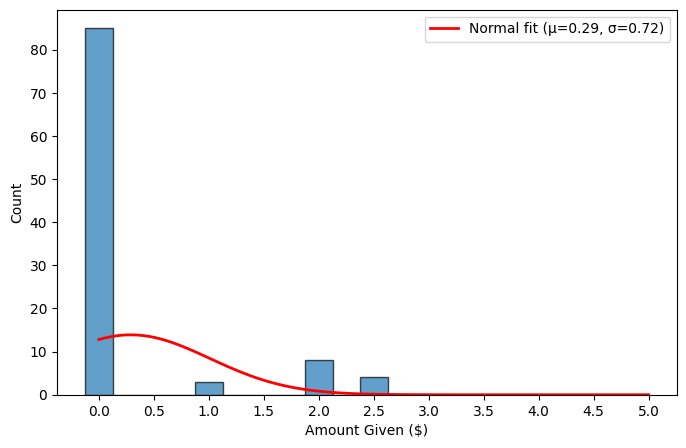

Ultimatum Game Offer: μ = 1.44, σ = 0.67


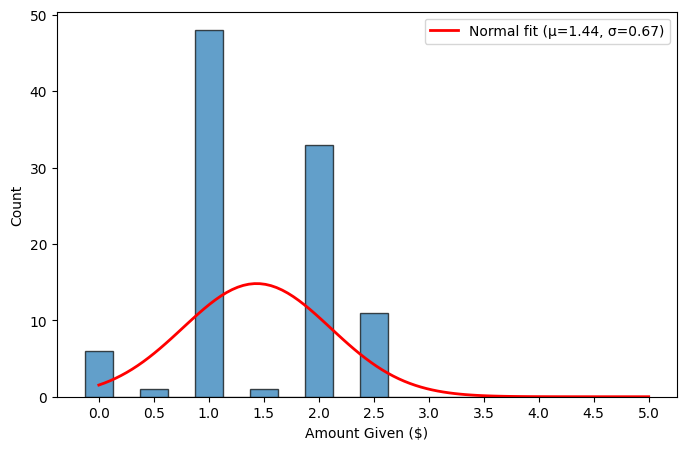

In [5]:
def plot_histogram_with_normal_fit(values: list[float], title: str, filename: str):
    mu, std = norm.fit(values)
    print(f"{title}: μ = {mu:.2f}, σ = {std:.2f}")

    x = np.linspace(0, 5, 100)
    plt.figure(figsize=(8, 5))
    counts, edges, _ = plt.hist(values, bins=np.arange(0, 5.25, 0.25), edgecolor="black", alpha=0.7, align="left")
    pdf = norm.pdf(x, mu, std)
    bin_width = edges[1] - edges[0]
    plt.plot(x, pdf * len(values) * bin_width, "r-", linewidth=2, label=f"Normal fit (μ={mu:.2f}, σ={std:.2f})")
    plt.xlabel("Amount Given ($)")
    plt.ylabel("Count")
    #plt.title(title)
    plt.xticks(np.arange(0, 5.25, 0.5))
    plt.legend()
    plt.savefig(f"assets/{filename}", bbox_inches="tight")
    plt.show()


dictator_amounts = [result.response.amount_given for result in dictatorship_game.results]
plot_histogram_with_normal_fit(dictator_amounts, "Dictatorship Game", "dictatorship_game_distribution.pdf")
ultimatum_offers = [result.propose_response.offer for result in ultimatum_game.results]
plot_histogram_with_normal_fit(ultimatum_offers, "Ultimatum Game Offer", "ultimatum_game_offer_distribution.pdf")

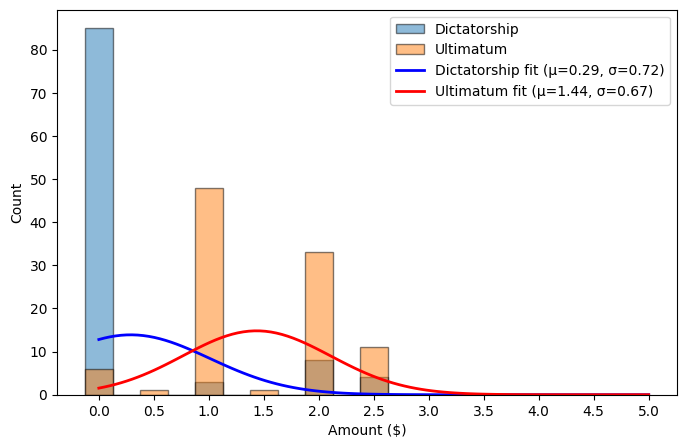

Dictatorship: μ = 0.29, σ = 0.72
Ultimatum:   μ = 1.44, σ = 0.67


In [6]:
# Compare distributions
mu_dict, std_dict = norm.fit(dictator_amounts)
mu_ulti, std_ulti = norm.fit(ultimatum_offers)

x = np.linspace(0, 5, 100)
bin_width = 0.25

plt.figure(figsize=(8, 5))
plt.hist(dictator_amounts, bins=np.arange(0, 5.25, 0.25), alpha=0.5, label="Dictatorship", edgecolor="black", align="left")
plt.hist(ultimatum_offers, bins=np.arange(0, 5.25, 0.25), alpha=0.5, label="Ultimatum", edgecolor="black", align="left")
plt.plot(x, norm.pdf(x, mu_dict, std_dict) * len(dictator_amounts) * bin_width, "b-", linewidth=2, label=f"Dictatorship fit (μ={mu_dict:.2f}, σ={std_dict:.2f})")
plt.plot(x, norm.pdf(x, mu_ulti, std_ulti) * len(ultimatum_offers) * bin_width, "r-", linewidth=2, label=f"Ultimatum fit (μ={mu_ulti:.2f}, σ={std_ulti:.2f})")
plt.xlabel("Amount ($)")
plt.ylabel("Count")
#plt.title("Dictatorship vs Ultimatum Game")
plt.xticks(np.arange(0, 5.25, 0.5))
plt.legend()
plt.savefig("assets/dictatorship_vs_ultimatum_distributions.pdf", bbox_inches="tight")
plt.show()

print(f"Dictatorship: μ = {mu_dict:.2f}, σ = {std_dict:.2f}")
print(f"Ultimatum:   μ = {mu_ulti:.2f}, σ = {std_ulti:.2f}")

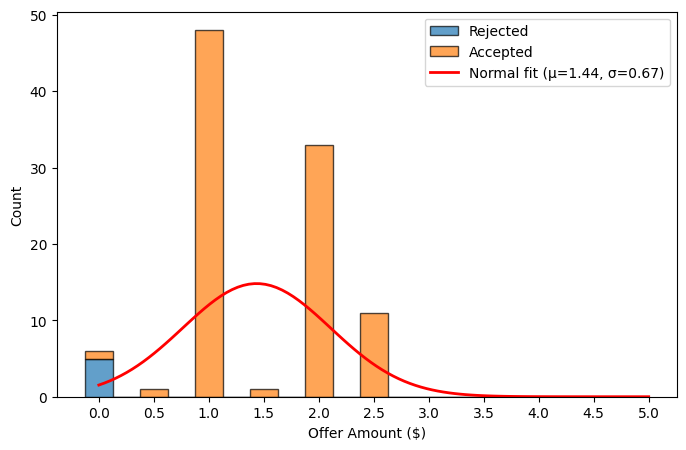

Offer distribution: μ = 1.44, σ = 0.67


In [7]:
# Ultimatum game: offers accepted vs rejected
offers = [result.propose_response.offer for result in ultimatum_game.results]
decisions = [result.respond_response.decision for result in ultimatum_game.results]

accepted = [o for o, d in zip(offers, decisions) if d == "accept"]
rejected = [o for o, d in zip(offers, decisions) if d == "reject"]

plt.figure(figsize=(8, 5))
plt.hist([rejected, accepted], bins=np.arange(0, 5.25, 0.25), stacked=True, edgecolor="black", alpha=0.7, label=["Rejected", "Accepted"],align='left')

# Add distribution fit for all offers
mu, std = norm.fit(offers)
x = np.linspace(0, 5, 100)
bin_width = 0.25
plt.plot(x, norm.pdf(x, mu, std) * len(offers) * bin_width, "r-", linewidth=2, label=f"Normal fit (μ={mu:.2f}, σ={std:.2f})")

plt.xlabel("Offer Amount ($)")
plt.ylabel("Count")
#plt.title("Ultimatum Game: Accepted vs Rejected Offers")
plt.xticks(np.arange(0, 5.25, 0.5))
plt.legend()
plt.savefig("assets/ultimatum_accepted_vs_rejected.pdf", bbox_inches="tight")
plt.show()
print(f"Offer distribution: μ = {mu:.2f}, σ = {std:.2f}")

### Comments

In the dictatorship game, the agents are not forgiving in a sense and they are playing their optimal strategy. They still in some small amount of cases gift some money to their opponent.

In the ultimatum game, the situation is however different. Since their opponents have actual power to deny the money, the agents are keen on giving their opponents at least something. The distribution is different and more generous as in the former case. 
In addition, the receivers of the ultimatum are rejecting the offer and denying money to everybody only in case they receive nothing. That means the receivers are playing their optimal strategy. 

# Dictatorship and ultimatum games - comparison to original paper

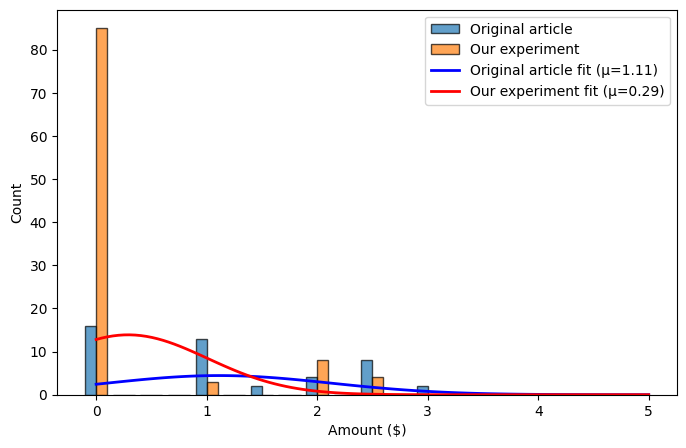

Dictator game
Original article: μ = 1.11, σ = 1.01
Our experiment: μ = 0.29, σ = 0.72


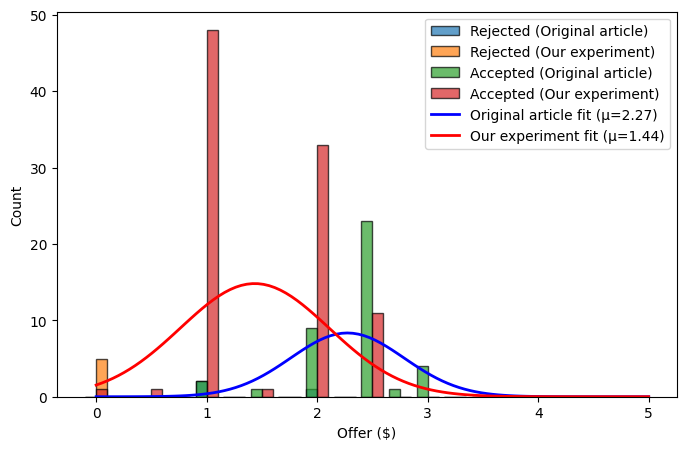

Ultimatum game
Original article: μ = 2.27, σ = 0.51
Our experiment: μ = 1.44, σ = 0.67


In [8]:
original_data_df = pd.read_csv("dictator_game_original_paper_data.csv")
pay_data_df = original_data_df[original_data_df["Pay/No Pay"] == "Pay"]
dictator_game_df = pay_data_df[pay_data_df["Game"] == "Dictator"]
ultimatum_game_df = pay_data_df[pay_data_df["Game"] == "Ultimatum"]

original_dictator = dictator_game_df["Value"].tolist()
original_ulti_accept = ultimatum_game_df[ultimatum_game_df["Rejected"] == False]["Value"].tolist()
original_ulti_reject = ultimatum_game_df[ultimatum_game_df["Rejected"] == True]["Value"].tolist()

# Dictator Game: Original paper vs Our experiment
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.arange(0, 5.25, 0.25)
ax.hist([original_dictator, dictator_amounts], bins=bins, histtype="bar", alpha=0.7, edgecolor="black", label=["Original article", "Our experiment"], align='left')

mu_orig, std_orig = norm.fit(original_dictator)
mu_exp, std_exp = norm.fit(dictator_amounts)
x = np.linspace(0, 5, 100)
bin_width = 0.25
ax.plot(x, norm.pdf(x, mu_orig, std_orig) * len(original_dictator) * bin_width, "b-", linewidth=2, label=f"Original article fit (μ={mu_orig:.2f})")
ax.plot(x, norm.pdf(x, mu_exp, std_exp) * len(dictator_amounts) * bin_width, "r-", linewidth=2, label=f"Our experiment fit (μ={mu_exp:.2f})")

ax.set_xlabel("Amount ($)")
ax.set_ylabel("Count")
#ax.set_title("Dictator Game: Original article vs Our experiment")
ax.legend()
plt.savefig("assets/dictator_original_vs_experiment.pdf", bbox_inches="tight")
plt.show()

print("Dictator game")
print(f"Original article: μ = {mu_orig:.2f}, σ = {std_orig:.2f}")
print(f"Our experiment: μ = {mu_exp:.2f}, σ = {std_exp:.2f}")

# Ultimatum Game: Original article vs Our experiment (Accepted vs Rejected)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist([original_ulti_reject, rejected], bins=bins, histtype="bar", alpha=0.7, edgecolor="black", label=["Rejected (Original article)", "Rejected (Our experiment)"], align='left')
ax.hist([original_ulti_accept, accepted], bins=bins, histtype="bar", alpha=0.7, edgecolor="black", label=["Accepted (Original article)", "Accepted (Our experiment)"], align='left')

mu_orig, std_orig = norm.fit(original_ulti_accept + original_ulti_reject)
mu_exp, std_exp = norm.fit(ultimatum_offers)
ax.plot(x, norm.pdf(x, mu_orig, std_orig) * len(original_ulti_accept + original_ulti_reject) * bin_width, "b-", linewidth=2, label=f"Original article fit (μ={mu_orig:.2f})")
ax.plot(x, norm.pdf(x, mu_exp, std_exp) * len(ultimatum_offers) * bin_width, "r-", linewidth=2, label=f"Our experiment fit (μ={mu_exp:.2f})")

ax.set_xlabel("Offer ($)")
ax.set_ylabel("Count")
#ax.set_title("Ultimatum Game: Original article vs Our experiment")
ax.legend()
plt.savefig("assets/ultimatum_original_vs_experiment.pdf", bbox_inches="tight")
plt.show()

print("Ultimatum game")

print(f"Original article: μ = {mu_orig:.2f}, σ = {std_orig:.2f}")
print(f"Our experiment: μ = {mu_exp:.2f}, σ = {std_exp:.2f}")

Dictator game original paper


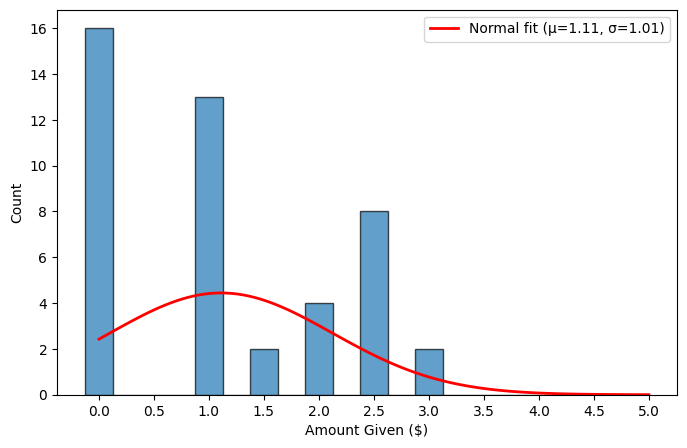

Dictator Game (Original): μ = 1.11, σ = 1.01
Ultimatum game original paper


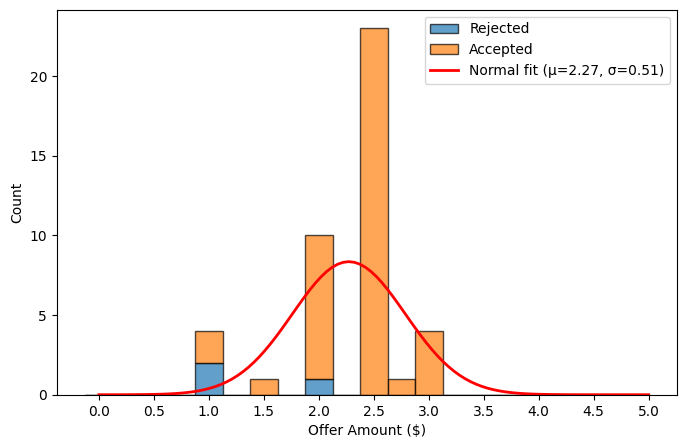

Ultimatum Game (Original): μ = 2.27, σ = 0.51


In [9]:
# Original paper distributions only
bins = np.arange(0, 5.25, 0.25)
bin_width = 0.25
x = np.linspace(0, 5, 100)

print('Dictator game original paper')
# Dictator Game - Original paper distribution
mu_dict_orig, std_dict_orig = norm.fit(original_dictator)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(original_dictator, bins=bins, edgecolor="black", alpha=0.7, align="left")
ax.plot(x, norm.pdf(x, mu_dict_orig, std_dict_orig) * len(original_dictator) * bin_width, "r-", linewidth=2, label=f"Normal fit (μ={mu_dict_orig:.2f}, σ={std_dict_orig:.2f})")
ax.set_xlabel("Amount Given ($)")
ax.set_ylabel("Count")
#ax.set_title("Dictator Game Distribution - Original Paper")
ax.set_xticks(np.arange(0, 5.25, 0.5))
ax.legend()
plt.savefig("assets/dictator_game_original_paper.pdf", bbox_inches="tight")
plt.show()
print(f"Dictator Game (Original): μ = {mu_dict_orig:.2f}, σ = {std_dict_orig:.2f}")

print('Ultimatum game original paper')
# Ultimatum Game - Original paper distribution (Accepted vs Rejected)
mu_ulti_orig, std_ulti_orig = norm.fit(original_ulti_accept + original_ulti_reject)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist([original_ulti_reject, original_ulti_accept], bins=bins, stacked=True, edgecolor="black", alpha=0.7, label=["Rejected", "Accepted"], align="left")
ax.plot(x, norm.pdf(x, mu_ulti_orig, std_ulti_orig) * len(original_ulti_accept + original_ulti_reject) * bin_width, "r-", linewidth=2, label=f"Normal fit (μ={mu_ulti_orig:.2f}, σ={std_ulti_orig:.2f})")
ax.set_xlabel("Offer Amount ($)")
ax.set_ylabel("Count")
#ax.set_title("Ultimatum Game Distribution - Original Paper")
ax.set_xticks(np.arange(0, 5.25, 0.5))
ax.legend()
plt.savefig("assets/ultimatum_game_original_paper.pdf", bbox_inches="tight")
plt.show()
print(f"Ultimatum Game (Original): μ = {mu_ulti_orig:.2f}, σ = {std_ulti_orig:.2f}")

In [10]:
from scipy.stats import ttest_ind, mannwhitneyu, ks_2samp

original_ulti_all = original_ulti_accept + original_ulti_reject

def compare_distributions(name: str, data1: list, data2: list, label1: str, label2: str):
    print(f"=== {name} ===")
    print(f"{label1}: μ = {np.mean(data1):.2f}, median = {np.median(data1):.2f}, n = {len(data1)}")
    print(f"{label2}: μ = {np.mean(data2):.2f}, median = {np.median(data2):.2f}, n = {len(data2)}")
    print()
    
    # Student's t-test (parametric, compares means)
    t_stat, t_p = ttest_ind(data1, data2)
    print(f"Student's t-test:")
    print(f"  t-statistic = {t_stat:.3f}, p-value = {t_p:.4e}")
    print(f"  Significant difference (α=0.05): {'Yes' if t_p < 0.05 else 'No'}")
    print()
    
    # Mann-Whitney U test (non-parametric, compares distributions)
    u_stat, mw_p = mannwhitneyu(data1, data2, alternative="two-sided")
    print(f"Mann-Whitney U test:")
    print(f"  U-statistic = {u_stat:.1f}, p-value = {mw_p:.4e}")
    print(f"  Significant difference (α=0.05): {'Yes' if mw_p < 0.05 else 'No'}")
    print()
    
    # Kolmogorov-Smirnov test (compares entire distributions)
    ks_stat, ks_p = ks_2samp(data1, data2)
    print(f"Kolmogorov-Smirnov test:")
    print(f"  KS-statistic = {ks_stat:.3f}, p-value = {ks_p:.4e}")
    print(f"  Significant difference (α=0.05): {'Yes' if ks_p < 0.05 else 'No'}")
    print()

compare_distributions("Dictator Game", original_dictator, dictator_amounts, "Original paper", "Our experiment")
compare_distributions("Ultimatum Game", original_ulti_all, ultimatum_offers, "Original paper", "Our experiment")

=== Dictator Game ===
Original paper: μ = 1.11, median = 1.00, n = 45
Our experiment: μ = 0.29, median = 0.00, n = 100

Student's t-test:
  t-statistic = 5.539, p-value = 1.4183e-07
  Significant difference (α=0.05): Yes

Mann-Whitney U test:
  U-statistic = 3332.5, p-value = 1.2429e-08
  Significant difference (α=0.05): Yes

Kolmogorov-Smirnov test:
  KS-statistic = 0.494, p-value = 1.9028e-07
  Significant difference (α=0.05): Yes

=== Ultimatum Game ===
Original paper: μ = 2.27, median = 2.50, n = 43
Our experiment: μ = 1.44, median = 1.00, n = 100

Student's t-test:
  t-statistic = 7.250, p-value = 2.5165e-11
  Significant difference (α=0.05): Yes

Mann-Whitney U test:
  U-statistic = 3578.0, p-value = 4.6043e-11
  Significant difference (α=0.05): Yes

Kolmogorov-Smirnov test:
  KS-statistic = 0.541, p-value = 1.0655e-08
  Significant difference (α=0.05): Yes

